# Encoding Numerical Features

### Two Techniques
         - Discretization(Binning)
         - Binarization

## Discretization 
   #### It is the process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that span the range of the variable's values. Discritization is also called binning, where bin is an alternative name for interval.
#### It is used to handel otliers and improve the value spread.
### Its types 
        - Unsupervised (Equal width, Equal Frequency, K-means Binning)
        - Supervised (Decision Tree Binning)
        - Custom Binning

### Equal Width 
    (max-min)/bin
    Handles outlier


### Equal Frequency
        Intervals = 10 
        Each interval contains 10% of total obsevations. Intervals are not in same width.
        Handels outlier
        prevent spreading of data.

### K-means Binning
        clusters are used means having specific distance in data.
        Interval = 5(centeroid) means randomly create interval in data. calculate distance 
                    for each point from centeroid and data which is nearest to centeroid are 
                    kept in  1 clusters 



In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score


In [5]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/covid_dataset.csv',usecols=['Age','Fever','Has_Covid'])

In [6]:
df

,Age,Fever,Has_Covid
0,56,102.4,No
1,19,101.6,No
2,76,102.0,No
3,65,99.7,No
4,25,102.1,Yes
...,...,...,...
995,41,102.0,No
996,76,100.9,No
997,35,100.6,No
998,13,99.5,Yes


In [7]:
df.shape

(1000, 3)

In [8]:
df.isnull().sum()

Age          0
Fever        0
Has_Covid    0
dtype: int64

In [19]:
x = df.iloc[:,0:2]
y= df.iloc[:,-1]

In [20]:
x

,Age,Fever
0,56,102.4
1,19,101.6
2,76,102.0
3,65,99.7
4,25,102.1
...,...,...
995,41,102.0
996,76,100.9
997,35,100.6
998,13,99.5


In [21]:
y

0       No
1       No
2       No
3       No
4      Yes
      ... 
995     No
996     No
997     No
998    Yes
999    Yes
Name: Has_Covid, Length: 1000, dtype: object

In [22]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
clf = DecisionTreeClassifier()

In [24]:
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

In [25]:
accuracy_score(y_test,y_pred)

0.46

In [26]:
np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy'))


np.float64(0.49499999999999994)

In [47]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')
kbin_Fever = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')

In [48]:
trf = ColumnTransformer([
    ('First',kbin_age,[0]),
    ('second',kbin_Fever,[1])
])

In [49]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.fit_transform(x_test)

In [50]:
trf.named_transformers_

{'First': KBinsDiscretizer(encode='ordinal', n_bins=15, strategy='kmeans'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15, strategy='kmeans')}

In [51]:
trf.named_transformers_['First'].bin_edges_

array([array([ 5.        ,  9.36904762, 15.34126984, 21.22222222, 26.62254902,
              31.92810458, 36.95906433, 42.07017544, 47.33333333, 53.76315789,
              60.21315789, 64.95      , 69.57692308, 74.67692308, 80.04444444,
              85.        ])                                                   ],
      dtype=object)

In [52]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age':x_train_trf[:,0],
    'Fever':x_train['Fever'],
    'Fever':x_train_trf[:,1]
})

In [53]:
output['age_labels']= pd.cut(x=x_train['Age'],bins=trf.named_transformers_['First'].bin_edges_[0].tolist())

output['fever_labels']= pd.cut(x=x_train['Fever'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [54]:
output.sample(5)

,age,Fever,age_labels,fever_labels
724,4.0,7.0,"(5.0, 9.369]","(101.048, 101.393]"
433,10.0,0.0,"(53.763, 60.213]","(99.664, 100.009]"
298,7.0,12.0,NaN,NaN
251,11.0,10.0,"(26.623, 31.928]","(101.048, 101.393]"
320,9.0,7.0,"(5.0, 9.369]","(101.393, 101.635]"


In [55]:
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred2= clf.predict(x_test_trf)

/opt/anaconda3/envs/DS/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [56]:
accuracy_score(y_test,y_pred2)

0.535

In [57]:
x_trf = trf.fit_transform(x)
np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy'))

np.float64(0.5)

In [65]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')
    kbin_Fever = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')

    trf = ColumnTransformer([
    ('First',kbin_age,[0]),
    ('second',kbin_Fever,[1])
    ])

    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(clf,x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")
    # plt.figure(figsize=(14,4))abs
    
    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()


    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fever'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x['Fever'])
    plt.title("After")

    plt.show()

    

0.503


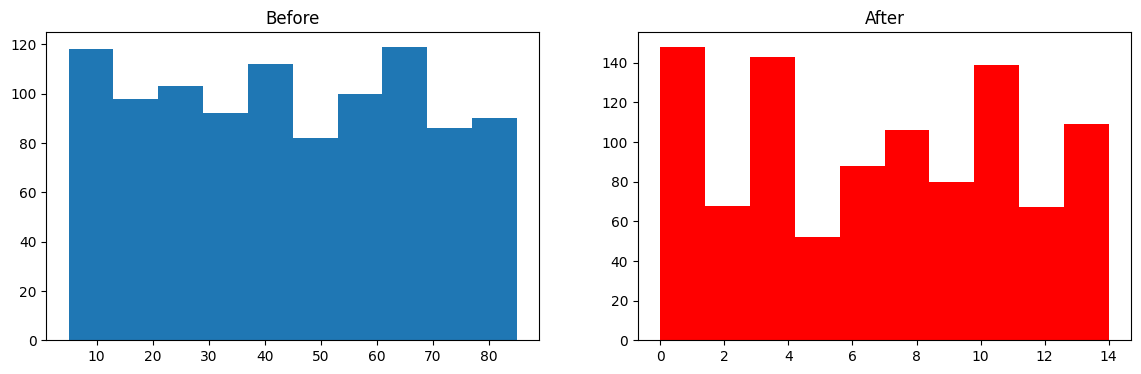

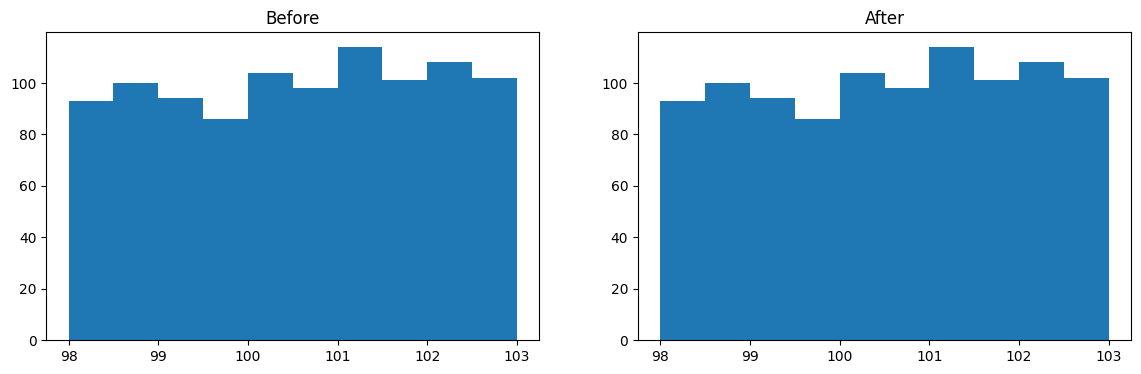

In [69]:
discretize(15,'kmeans')